In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('calories_data.csv')
df.head()

,user_id,gender,age,height,weight,duration,heart_rate,body_temp,user_id.1,calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,14861698,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,11179863,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,16180408,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,17771927,35.0


In [3]:
df.isnull().sum()

user_id       0
gender        0
age           0
height        0
weight        0
duration      0
heart_rate    0
body_temp     0
user_id.1     0
calories      0
dtype: int64

In [4]:
df=df.drop(columns=['user_id.1'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   user_id     15000 non-null  int64  
 1   gender      15000 non-null  int64  
 2   age         15000 non-null  int64  
 3   height      15000 non-null  float64
 4   weight      15000 non-null  float64
 5   duration    15000 non-null  float64
 6   heart_rate  15000 non-null  float64
 7   body_temp   15000 non-null  float64
 8   calories    15000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 1.0 MB


Text(0.5, 1.0, 'Fitness')

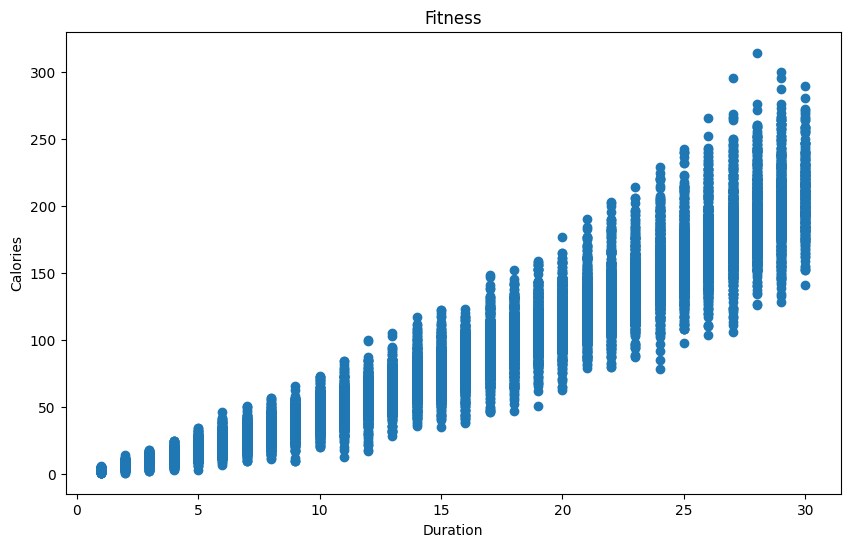

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(df['duration'],df['calories'])
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.title('Fitness')

<Axes: xlabel='duration', ylabel='calories'>

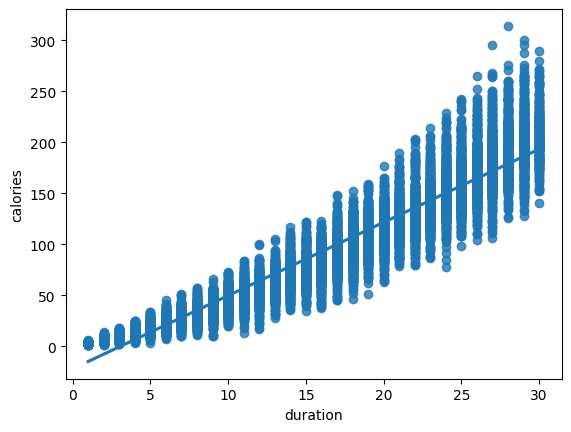

In [7]:
sns.regplot(x=df['duration'],y=df['calories'],data=df)

In [8]:
from sklearn.model_selection import train_test_split
x = df[["gender", "age", "height", "weight", "duration", "heart_rate", "body_temp"]]
y = df["calories"]
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LinearRegression



In [10]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
prediction=model.predict(x_test)

In [12]:
from sklearn.metrics import r2_score

score=r2_score(y_test,prediction)
print(score)

0.9670347432440104


In [13]:
y_test.values[:5]


array([ 17., 167.,  40.,  34.,  23.])

In [14]:
prediction[:5]

array([  9.22626829, 169.63375954,  43.83041464,  27.14239131,
        18.9313065 ])

In [15]:
from sklearn.ensemble import RandomForestRegressor

r_model=RandomForestRegressor()
r_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
r_prediction=r_model.predict(x_test)



In [17]:
from sklearn.metrics import r2_score

rand_score=r2_score(y_test,r_prediction)
print(rand_score)

0.9944627440586045


In [18]:
train_score=r2_score(y_train,model.predict(x_train))
test_score=r2_score(y_test,model.predict(x_test))
print(train_score,test_score)

0.9674171446203719 0.9670347432440104


In [19]:
r_train_score=r2_score(y_train,r_model.predict(x_train))
r_test_score=r2_score(y_test,r_model.predict(x_test))
print(r_train_score,r_test_score)

0.9992351912008663 0.9944627440586045


In [20]:
from sklearn.model_selection import cross_val_score

val_score=cross_val_score(model,x,y,cv=5,scoring="r2")
print("cv score",val_score)
print("mean",val_score.mean())

cv score [0.96712832 0.96658977 0.96769213 0.96828562 0.96606908]
mean 0.967152984018283


In [21]:
r_val_score=cross_val_score(r_model,x,y,cv=6,scoring="r2")
print(r_val_score)
print("mean",r_val_score.mean())

[0.99817169 0.99782392 0.99809967 0.99780171 0.99767816 0.99811646]
mean 0.9979486014903488


In [23]:

import joblib



joblib.dump(r_model,"fitness.pkl")

['fitness.pkl']